# Chapter 6: Algorithms



> *Computer Science is no more about computers than astronomy is about telescopes.*

> 

> E.W. Dijkstra



Algorithms often arrive long before the machines they run on. Classical algorithms predate 
classical computers by millennia. Quantum algorithms predate large-scale quantum computers 
by decades. These algorithms manipulate qubits to solve problems more efficiently than any 
known classical approach.



This chapter presents five quantum algorithms in order of increasing difficulty. Each builds 
on ideas from the previous ones. They all share a common framework:



1. Start the system in a classical state

2. Create a superposition of many states

3. Apply unitary operations to the superposition

4. Measure the qubits



The variations on this theme are where the magic lives.

In [1]:
import numpy as np

from numpy import kron, eye, sqrt, pi

from math import gcd, floor, log2

import matplotlib.pyplot as plt

from fractions import Fraction



# Single-qubit Hadamard

H1 = np.array([[1, 1], [1, -1]]) / sqrt(2)



def hadamard(n):

    """Walsh-Hadamard matrix for n qubits."""

    H = H1

    for _ in range(n - 1):

        H = kron(H, H1)

    return H



def basis_state(n_qubits, index):

    """Standard basis vector |index> in a 2^n-dimensional space."""

    N = 2**n_qubits

    v = np.zeros(N)

    v[index] = 1.0

    return v



def plot_probs(state, n_qubits=None, title='', highlight=None):

    """Bar chart of measurement probabilities."""

    probs = np.abs(state)**2

    N = len(probs)

    if n_qubits is None:

        n_qubits = int(log2(N))

    labels = [format(i, f'0{n_qubits}b') for i in range(N)]

    colors = ['#e74c3c' if i == highlight else '#3498db' for i in range(N)]

    fig, ax = plt.subplots(figsize=(max(4, N * 0.5), 3))

    ax.bar(range(N), probs, color=colors, tick_label=labels)

    ax.set_ylabel('Probability')

    if title:

        ax.set_title(title)

    plt.xticks(rotation=45 if n_qubits > 2 else 0, fontsize=8)

    plt.tight_layout()

    plt.show()

## 6.1 Deutsch's Algorithm



There are exactly four functions from $\{0,1\}$ to $\{0,1\}$:



| $f$ | $f(0)$ | $f(1)$ | Type |

|-----|--------|--------|------|

| $f_1$ | 0 | 0 | constant |

| $f_2$ | 0 | 1 | balanced |

| $f_3$ | 1 | 0 | balanced |

| $f_4$ | 1 | 1 | constant |



A function is **balanced** if $f(0) \neq f(1)$ (one-to-one). It is **constant** if 
$f(0) = f(1)$.



Deutsch's algorithm determines whether a black-box function is balanced or constant 
with a single function evaluation, where a classical computer always needs two.



### Building $U_f$ matrices



A quantum gate must be unitary (and therefore reversible). We encode $f$ as a 2-qubit 
gate $U_f$ that maps $|x, y\rangle \mapsto |x, y \oplus f(x)\rangle$, where $\oplus$ is XOR.



This makes $U_f$ its own inverse: applying it twice returns to the original state, since 
$y \oplus f(x) \oplus f(x) = y$.

In [2]:
def build_Uf_deutsch(f0, f1):

    """Build 4x4 U_f for a function f:{0,1}->{0,1} given f(0) and f(1).

    Rows/cols ordered as |00>, |01>, |10>, |11>.

    Maps |x,y> -> |x, y XOR f(x)>."""

    U = np.zeros((4, 4))

    for x in range(2):

        fx = f0 if x == 0 else f1

        for y in range(2):

            inp = 2*x + y

            out = 2*x + (y ^ fx)

            U[out, inp] = 1

    return U



# All four functions

functions = [

    (0, 0, 'f1: 0->0, 1->0 (constant)'),

    (0, 1, 'f2: 0->0, 1->1 (balanced)'),

    (1, 0, 'f3: 0->1, 1->0 (balanced)'),

    (1, 1, 'f4: 0->1, 1->1 (constant)'),

]



Ufs = {}

for f0, f1, label in functions:

    U = build_Uf_deutsch(f0, f1)

    Ufs[(f0, f1)] = U

    print(f'{label}')

    print(U.astype(int))

    # Verify self-inverse

    assert np.allclose(U @ U, np.eye(4)), f'{label} is not self-inverse!'

    # Verify unitary

    assert np.allclose(U @ U.T, np.eye(4)), f'{label} is not unitary!'

    print()

f1: 0->0, 1->0 (constant)
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]

f2: 0->0, 1->1 (balanced)
[[1 0 0 0]
 [0 1 0 0]
 [0 0 0 1]
 [0 0 1 0]]

f3: 0->1, 1->0 (balanced)
[[0 1 0 0]
 [1 0 0 0]
 [0 0 1 0]
 [0 0 0 1]]

f4: 0->1, 1->1 (constant)
[[0 1 0 0]
 [1 0 0 0]
 [0 0 0 1]
 [0 0 1 0]]



**Exercise 6.1.1.** Describe the matrices for the other three functions from $\{0,1\}$ to $\{0,1\}$.



*Solution.* We built all four above. The identity matrix corresponds to $f(x) = 0$ for all $x$ 
(the function does nothing to the output qubit). The NOT-on-second-qubit (swap rows for $y$) 
corresponds to $f(x) = 1$ for all $x$. The CNOT matrix corresponds to $f(x) = x$, and the 
anti-CNOT to $f(x) = \bar{x}$.

**Exercise 6.1.2.** What is the adjoint of the matrix in Equation (6.9)? Show that this matrix is its own inverse.



*Solution.* The matrix for the balanced function $f(0)=1, f(1)=0$ (our $f_3$ above) has only real entries 
and is symmetric, so its adjoint (conjugate transpose) equals itself. Since $U_f^2 = I$ (as we verified 
computationally above), the matrix is indeed its own inverse.

In [3]:
# Exercise 6.1.2: Verify adjoint = self, and self-inverse

U_f3 = Ufs[(1, 0)]

print('U_f3:')

print(U_f3.astype(int))

print(f'\nAdjoint equals self: {np.allclose(U_f3, U_f3.conj().T)}')

print(f'Self-inverse: {np.allclose(U_f3 @ U_f3, np.eye(4))}')

U_f3:
[[0 1 0 0]
 [1 0 0 0]
 [0 0 1 0]
 [0 0 0 1]]

Adjoint equals self: True
Self-inverse: True


**Exercise 6.1.3.** Give the unitary matrices for the other three functions. Show each is its own adjoint and unitary.



*Solution.* Already built and verified above. Each $U_f$ consists only of 0s and 1s, is symmetric, 
and satisfies $U_f^2 = I$. So each is Hermitian, unitary, and its own inverse.

In [4]:
# Exercise 6.1.3: All four are self-adjoint and unitary

for (f0, f1), U in Ufs.items():

    is_hermitian = np.allclose(U, U.conj().T)

    is_unitary = np.allclose(U @ U.conj().T, np.eye(4))

    print(f'f(0)={f0}, f(1)={f1}: Hermitian={is_hermitian}, Unitary={is_unitary}')

f(0)=0, f(1)=0: Hermitian=True, Unitary=True
f(0)=0, f(1)=1: Hermitian=True, Unitary=True
f(0)=1, f(1)=0: Hermitian=True, Unitary=True
f(0)=1, f(1)=1: Hermitian=True, Unitary=True


### Three attempts at a quantum algorithm



**Attempt 1:** Put the top qubit in superposition, leave the bottom as $|0\rangle$, apply $U_f$, measure.



The circuit is $U_f(H \otimes I)|0,0\rangle$. After applying $U_f$, we get 
$|\varphi_2\rangle = \frac{|0, f(0)\rangle + |1, f(1)\rangle}{\sqrt{2}}$.



Measuring gives 50-50 outcomes for the top qubit regardless of $f$. This tells us nothing about 
whether $f$ is balanced or constant.

In [5]:
# Attempt 1: H on top, identity on bottom, then U_f

I2 = np.eye(2)

phi0 = np.array([1, 0, 0, 0])  # |0,0>



HI = kron(H1, I2)

phi1 = HI @ phi0  # After H on top qubit



print('Attempt 1 results after U_f:')

for f0, f1, label in functions:

    phi2 = Ufs[(f0, f1)] @ phi1

    probs = np.abs(phi2)**2

    print(f'  {label}')

    print(f'    state: {np.round(phi2, 4)}')

    print(f'    P(top=0) = {probs[0]+probs[1]:.2f}, P(top=1) = {probs[2]+probs[3]:.2f}')

Attempt 1 results after U_f:
  f1: 0->0, 1->0 (constant)
    state: [0.7071 0.     0.7071 0.    ]
    P(top=0) = 0.50, P(top=1) = 0.50
  f2: 0->0, 1->1 (balanced)
    state: [0.7071 0.     0.     0.7071]
    P(top=0) = 0.50, P(top=1) = 0.50
  f3: 0->1, 1->0 (balanced)
    state: [0.     0.7071 0.7071 0.    ]
    P(top=0) = 0.50, P(top=1) = 0.50
  f4: 0->1, 1->1 (constant)
    state: [0.     0.7071 0.     0.7071]
    P(top=0) = 0.50, P(top=1) = 0.50


**Attempt 2:** Leave the top qubit as $|x\rangle$, put the bottom into $\frac{|0\rangle - |1\rangle}{\sqrt{2}}$ via $H|1\rangle$.



After applying $U_f$, the phase kickback gives us $(-1)^{f(x)}|x\rangle\frac{|0\rangle - |1\rangle}{\sqrt{2}}$.



The phase $(-1)^{f(x)}$ tags each input, but with only one classical input $|x\rangle$, measuring the top 
qubit still yields $|x\rangle$ with certainty. The phase is invisible.

**Exercise 6.1.4.** Using the matrices from Exercise 6.1.3, determine $|\varphi_2\rangle$ for the other three functions.



*Solution.* With Attempt 1 (top in superposition, bottom as $|0\rangle$):

In [6]:
# Exercise 6.1.4: phi2 for each function (Attempt 1 setup)

phi1_attempt1 = HI @ phi0

for f0, f1, label in functions:

    phi2 = Ufs[(f0, f1)] @ phi1_attempt1

    labels_bin = ['|00>', '|01>', '|10>', '|11>']

    terms = [f'{c:.4f}{l}' for c, l in zip(phi2, labels_bin) if abs(c) > 1e-10]

    print(f'{label}:')

    print(f'  |phi2> = {" + ".join(terms)}')

f1: 0->0, 1->0 (constant):
  |phi2> = 0.7071|00> + 0.7071|10>
f2: 0->0, 1->1 (balanced):
  |phi2> = 0.7071|00> + 0.7071|11>
f3: 0->1, 1->0 (balanced):
  |phi2> = 0.7071|01> + 0.7071|10>
f4: 0->1, 1->1 (constant):
  |phi2> = 0.7071|01> + 0.7071|11>


### The correct circuit: Deutsch's algorithm



The key insight: put **both** qubits into superposition. Start with $|0,1\rangle$, apply 
Hadamard to both, apply $U_f$, then apply Hadamard to the top qubit and measure it.



The matrix form: $(H \otimes I) \cdot U_f \cdot (H \otimes H) |0,1\rangle$



The states at each stage:



- $|\varphi_0\rangle = |0,1\rangle$

- $|\varphi_1\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}} \otimes \frac{|0\rangle - |1\rangle}{\sqrt{2}}$

- $|\varphi_2\rangle = \frac{(-1)^{f(0)}|0\rangle + (-1)^{f(1)}|1\rangle}{\sqrt{2}} \otimes \frac{|0\rangle - |1\rangle}{\sqrt{2}}$

- $|\varphi_3\rangle$: after final Hadamard on top qubit



If $f$ is constant, the top qubit of $|\varphi_2\rangle$ is $\pm\frac{|0\rangle + |1\rangle}{\sqrt{2}}$, so $H$ maps it back to $|0\rangle$.

If $f$ is balanced, the top qubit is $\pm\frac{|0\rangle - |1\rangle}{\sqrt{2}}$, so $H$ maps it to $|1\rangle$.



Measuring $|0\rangle$ means constant. Measuring $|1\rangle$ means balanced. One evaluation of $f$.

In [7]:
def deutsch(f0, f1):

    """Run Deutsch's algorithm. Return all intermediate states and the result."""

    U_f = build_Uf_deutsch(f0, f1)

    

    # |phi0> = |0,1>

    phi0 = np.array([0, 1, 0, 0])  # |01>

    

    # |phi1> = (H x H)|0,1>

    HH = kron(H1, H1)

    phi1 = HH @ phi0

    

    # |phi2> = U_f |phi1>

    phi2 = U_f @ phi1

    

    # |phi3> = (H x I)|phi2>

    HI = kron(H1, I2)

    phi3 = HI @ phi2

    

    # Measure top qubit: P(top=0) = |<00|phi3>|^2 + |<01|phi3>|^2

    p_top0 = abs(phi3[0])**2 + abs(phi3[1])**2

    p_top1 = abs(phi3[2])**2 + abs(phi3[3])**2

    

    result = 'constant' if p_top0 > 0.5 else 'balanced'

    

    return {'phi0': phi0, 'phi1': phi1, 'phi2': phi2, 'phi3': phi3,

            'p_top0': p_top0, 'p_top1': p_top1, 'result': result}



# Run on all four functions, tracing states

for f0, f1, label in functions:

    r = deutsch(f0, f1)

    print(f'=== {label} ===')

    for name in ['phi0', 'phi1', 'phi2', 'phi3']:

        print(f'  |{name}> = {np.round(r[name], 4)}')

    print(f'  P(top=0) = {r["p_top0"]:.4f}, P(top=1) = {r["p_top1"]:.4f}')

    print(f'  Result: {r["result"]}')

    actual = 'constant' if f0 == f1 else 'balanced'

    assert r['result'] == actual, f'WRONG! Expected {actual}'

    print(f'  Correct!\n')

=== f1: 0->0, 1->0 (constant) ===
  |phi0> = [0 1 0 0]
  |phi1> = [ 0.5 -0.5  0.5 -0.5]
  |phi2> = [ 0.5 -0.5  0.5 -0.5]
  |phi3> = [ 0.7071 -0.7071  0.      0.    ]
  P(top=0) = 1.0000, P(top=1) = 0.0000
  Result: constant
  Correct!

=== f2: 0->0, 1->1 (balanced) ===
  |phi0> = [0 1 0 0]
  |phi1> = [ 0.5 -0.5  0.5 -0.5]
  |phi2> = [ 0.5 -0.5 -0.5  0.5]
  |phi3> = [ 0.      0.      0.7071 -0.7071]
  P(top=0) = 0.0000, P(top=1) = 1.0000
  Result: balanced
  Correct!

=== f3: 0->1, 1->0 (balanced) ===
  |phi0> = [0 1 0 0]
  |phi1> = [ 0.5 -0.5  0.5 -0.5]
  |phi2> = [-0.5  0.5  0.5 -0.5]
  |phi3> = [ 0.      0.     -0.7071  0.7071]
  P(top=0) = 0.0000, P(top=1) = 1.0000
  Result: balanced
  Correct!

=== f4: 0->1, 1->1 (constant) ===
  |phi0> = [0 1 0 0]
  |phi1> = [ 0.5 -0.5  0.5 -0.5]
  |phi2> = [-0.5  0.5 -0.5  0.5]
  |phi3> = [-0.7071  0.7071  0.      0.    ]
  P(top=0) = 1.0000, P(top=1) = 0.0000
  Result: constant
  Correct!



**Exercise 6.1.5.** For each of the other three functions, describe what $|\varphi_2\rangle$ would be.



*Solution.* We traced all four functions above. The pattern:

- $f_1$ (constant 0): top qubit of $|\varphi_2\rangle$ is $+\frac{|0\rangle + |1\rangle}{\sqrt{2}}$

- $f_2$ (balanced, identity): top qubit is $+\frac{|0\rangle - |1\rangle}{\sqrt{2}}$

- $f_3$ (balanced, NOT): top qubit is $-\frac{|0\rangle - |1\rangle}{\sqrt{2}}$

- $f_4$ (constant 1): top qubit is $-\frac{|0\rangle + |1\rangle}{\sqrt{2}}$



The $\pm$ global phase does not affect measurement. Constant functions leave the top qubit in the 
$|+\rangle$ state; balanced functions put it in the $|-\rangle$ state.

**Exercise 6.1.6.** For each of the other three functions, calculate $|\varphi_3\rangle$.



*Solution.* Already computed above. After the final Hadamard:

- Constant functions ($f_1, f_4$): top qubit collapses to $|0\rangle$ with certainty

- Balanced functions ($f_2, f_3$): top qubit collapses to $|1\rangle$ with certainty



The global phase $\pm 1$ vanishes upon measurement.

In [8]:
# Exercise 6.1.6: Verify |phi3> for all functions

for f0, f1, label in functions:

    r = deutsch(f0, f1)

    print(f'{label}:')

    print(f'  |phi3> = {np.round(r["phi3"], 4)}')

    print(f'  Top qubit: |{0 if r["p_top0"] > 0.5 else 1}> => {r["result"]}\n')

f1: 0->0, 1->0 (constant):
  |phi3> = [ 0.7071 -0.7071  0.      0.    ]
  Top qubit: |0> => constant

f2: 0->0, 1->1 (balanced):
  |phi3> = [ 0.      0.      0.7071 -0.7071]
  Top qubit: |1> => balanced

f3: 0->1, 1->0 (balanced):
  |phi3> = [ 0.      0.     -0.7071  0.7071]
  Top qubit: |1> => balanced

f4: 0->1, 1->1 (constant):
  |phi3> = [-0.7071  0.7071  0.      0.    ]
  Top qubit: |0> => constant



### The intuition: change of basis



Deutsch's algorithm is really a change of basis. The first Hadamards translate from the 
computational basis to a basis where $f$ can be evaluated on all inputs simultaneously. The 
final Hadamard translates back. In the computational basis, we can only ask "what is $f(0)$?" 
and "what is $f(1)$?" separately. In the Hadamard basis, we can ask "is $f$ balanced or 
constant?" directly. The quantum computer answers a different, more useful question in a single shot.

## 6.2 The Deutsch-Jozsa Algorithm



Deutsch's algorithm handles 1-bit inputs. The Deutsch-Jozsa algorithm generalizes to $n$-bit 
inputs: functions $f: \{0,1\}^n \to \{0,1\}$ that are promised to be either balanced (exactly half 
the inputs map to 0) or constant (all inputs map to the same value).



Classically, determining this requires up to $2^{n-1} + 1$ evaluations in the worst case. The 
quantum algorithm does it in one.



### The $H^{\otimes n}$ matrix



The entry at row $\mathbf{i}$, column $\mathbf{j}$ of $H^{\otimes n}$ is:



$$H^{\otimes n}[\mathbf{i}, \mathbf{j}] = \frac{1}{\sqrt{2^n}}(-1)^{\langle \mathbf{i}, \mathbf{j}\rangle}$$



where $\langle \mathbf{i}, \mathbf{j}\rangle = i_0 \wedge j_0 \oplus i_1 \wedge j_1 \oplus \cdots \oplus i_{n-1} \wedge j_{n-1}$ 
counts the parity of positions where both bits are 1.

**Exercise 6.2.1.** How many functions are there from $\{0,1\}^n$ to $\{0,1\}$? How many balanced? How many constant?



*Solution.* Total functions: $2^{2^n}$ (each of the $2^n$ inputs can map to 0 or 1). Constant: exactly 2 
(all-zeros or all-ones). Balanced: $\binom{2^n}{2^{n-1}}$ (choose which half of inputs map to 0).

In [9]:
# Exercise 6.2.1

from math import comb

for n in range(1, 5):

    total = 2**(2**n)

    balanced = comb(2**n, 2**(n-1))

    print(f'n={n}: total={total}, constant=2, balanced={balanced}')

n=1: total=4, constant=2, balanced=2
n=2: total=16, constant=2, balanced=6
n=3: total=256, constant=2, balanced=70
n=4: total=65536, constant=2, balanced=12870


### The algorithm



The circuit: $(H^{\otimes n} \otimes I) \cdot U_f \cdot (H^{\otimes n} \otimes H) |\mathbf{0}, 1\rangle$



States:

- $|\varphi_0\rangle = |\mathbf{0}, 1\rangle$

- $|\varphi_1\rangle = \frac{\sum_{\mathbf{x}} |\mathbf{x}\rangle}{\sqrt{2^n}} \otimes \frac{|0\rangle - |1\rangle}{\sqrt{2}}$

- $|\varphi_2\rangle = \frac{\sum_{\mathbf{x}} (-1)^{f(\mathbf{x})} |\mathbf{x}\rangle}{\sqrt{2^n}} \otimes \frac{|0\rangle - |1\rangle}{\sqrt{2}}$

- $|\varphi_3\rangle$: apply $H^{\otimes n}$ to the top $n$ qubits



If $f$ is constant, the top qubits collapse to $|\mathbf{0}\rangle$ with certainty. If $f$ is balanced, 
the probability of measuring $|\mathbf{0}\rangle$ is exactly 0. One measurement distinguishes the two.

In [10]:
def build_Uf_dj(n, f_values):

    """Build U_f for Deutsch-Jozsa: n-qubit input + 1 control qubit.

    f_values: list of length 2^n giving f(x) for x = 0, 1, ..., 2^n - 1.

    Maps |x, y> -> |x, y XOR f(x)>."""

    N = 2**n

    dim = 2 * N  # n+1 qubits total

    U = np.zeros((dim, dim))

    for x in range(N):

        for y in range(2):

            inp = 2*x + y

            out = 2*x + (y ^ f_values[x])

            U[out, inp] = 1

    return U



def deutsch_jozsa(n, f_values):

    """Run Deutsch-Jozsa on an n-bit function. Returns 'constant' or 'balanced'."""

    N = 2**n

    dim = 2 * N

    

    # Build U_f

    U_f = build_Uf_dj(n, f_values)

    

    # |0...0, 1>

    phi0 = np.zeros(dim)

    phi0[1] = 1.0  # |0...0, 1> in our ordering (top n qubits = 0, bottom = 1)

    

    # Apply H^n x H

    Hn = hadamard(n)

    HnH = kron(Hn, H1)

    phi1 = HnH @ phi0

    

    # Apply U_f

    phi2 = U_f @ phi1

    

    # Apply H^n x I to top qubits

    HnI = kron(Hn, np.eye(2))

    phi3 = HnI @ phi2

    

    # Probability of top qubits being |0...0>

    # |0...0> corresponds to indices 0 and 1 (bottom qubit can be 0 or 1)

    p_zero = abs(phi3[0])**2 + abs(phi3[1])**2

    

    return 'constant' if p_zero > 0.5 else 'balanced'



# n=2 examples

print('=== n=2 Deutsch-Jozsa ===')

test_cases_n2 = [

    ([0, 0, 0, 0], 'constant'),

    ([1, 1, 1, 1], 'constant'),

    ([0, 1, 1, 0], 'balanced'),

    ([1, 0, 0, 1], 'balanced'),

    ([0, 0, 1, 1], 'balanced'),

    ([1, 1, 0, 0], 'balanced'),

]

for f_vals, expected in test_cases_n2:

    result = deutsch_jozsa(2, f_vals)

    status = 'ok' if result == expected else 'FAIL'

    print(f'  f={f_vals} => {result} (expected {expected}) [{status}]')

=== n=2 Deutsch-Jozsa ===
  f=[0, 0, 0, 0] => constant (expected constant) [ok]
  f=[1, 1, 1, 1] => constant (expected constant) [ok]
  f=[0, 1, 1, 0] => balanced (expected balanced) [ok]
  f=[1, 0, 0, 1] => balanced (expected balanced) [ok]
  f=[0, 0, 1, 1] => balanced (expected balanced) [ok]
  f=[1, 1, 0, 0] => balanced (expected balanced) [ok]


In [11]:
# n=3 examples

print('=== n=3 Deutsch-Jozsa ===')

test_cases_n3 = [

    ([0]*8, 'constant'),

    ([1]*8, 'constant'),

    ([0,1,1,0,1,0,0,1], 'balanced'),

    ([1,0,0,1,0,1,1,0], 'balanced'),

]

for f_vals, expected in test_cases_n3:

    result = deutsch_jozsa(3, f_vals)

    status = 'ok' if result == expected else 'FAIL'

    print(f'  f={f_vals} => {result} (expected {expected}) [{status}]')

=== n=3 Deutsch-Jozsa ===
  f=[0, 0, 0, 0, 0, 0, 0, 0] => constant (expected constant) [ok]
  f=[1, 1, 1, 1, 1, 1, 1, 1] => constant (expected constant) [ok]
  f=[0, 1, 1, 0, 1, 0, 0, 1] => balanced (expected balanced) [ok]
  f=[1, 0, 0, 1, 0, 1, 1, 0] => balanced (expected balanced) [ok]


**Exercise 6.2.2.** Consider the balanced function from $\{0,1\}^2$ to $\{0,1\}$ where $f(00)=0, f(01)=0, f(10)=1, f(11)=1$. Give the corresponding 8-by-8 unitary matrix.



*Solution.* The matrix $U_f$ maps $|\mathbf{x}, y\rangle \to |\mathbf{x}, y \oplus f(\mathbf{x})\rangle$. For inputs where $f(\mathbf{x})=0$, the 
matrix acts as identity on the control qubit. Where $f(\mathbf{x})=1$, it flips the control qubit.

In [12]:
# Exercise 6.2.2

f_622 = [0, 0, 1, 1]  # f(00)=0, f(01)=0, f(10)=1, f(11)=1

U_622 = build_Uf_dj(2, f_622)

print('U_f for Exercise 6.2.2:')

print(U_622.astype(int))

U_f for Exercise 6.2.2:
[[1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0]]


**Exercise 6.2.3.** Consider the constant function from $\{0,1\}^2$ to $\{0,1\}$ that always outputs 1. Give the corresponding unitary matrix.



*Solution.* When $f(\mathbf{x}) = 1$ for all $\mathbf{x}$, the control qubit always flips: $|y\rangle \to |y \oplus 1\rangle = |\bar{y}\rangle$. 
The matrix swaps every pair of rows that differ only in the last bit.

In [13]:
# Exercise 6.2.3

f_623 = [1, 1, 1, 1]  # constant 1

U_623 = build_Uf_dj(2, f_623)

print('U_f for constant-1 function:')

print(U_623.astype(int))

# This is I_4 tensor NOT

print(f'\nEquals I_4 x NOT: {np.allclose(U_623, kron(np.eye(4), np.array([[0,1],[1,0]])))}')

U_f for constant-1 function:
[[0 1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0]]

Equals I_4 x NOT: True


**Exercise 6.2.4.** Prove by induction that the scalar coefficient of $H^{\otimes n}$ is $\frac{1}{\sqrt{2^n}} = 2^{-n/2}$.



*Solution.* Base case: $H = \frac{1}{\sqrt{2}} \cdot \begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix}$, so the coefficient is $\frac{1}{\sqrt{2^1}}$. 
Inductive step: $H^{\otimes (n+1)} = H^{\otimes n} \otimes H$. The Kronecker product multiplies the scalar 
coefficients, giving $\frac{1}{\sqrt{2^n}} \cdot \frac{1}{\sqrt{2}} = \frac{1}{\sqrt{2^{n+1}}}$.

In [14]:
# Exercise 6.2.4: Verify the coefficient

for n in range(1, 6):

    Hn = hadamard(n)

    # The (0,0) entry should be 1/sqrt(2^n)

    expected = 1 / sqrt(2**n)

    actual = Hn[0, 0]

    print(f'n={n}: H[0,0] = {actual:.6f}, 1/sqrt(2^{n}) = {expected:.6f}, match={np.isclose(actual, expected)}')

n=1: H[0,0] = 0.707107, 1/sqrt(2^1) = 0.707107, match=True
n=2: H[0,0] = 0.500000, 1/sqrt(2^2) = 0.500000, match=True
n=3: H[0,0] = 0.353553, 1/sqrt(2^3) = 0.353553, match=True
n=4: H[0,0] = 0.250000, 1/sqrt(2^4) = 0.250000, match=True
n=5: H[0,0] = 0.176777, 1/sqrt(2^5) = 0.176777, match=True


**Exercise 6.2.5.** What would happen if the given function was neither balanced nor constant? What would our algorithm produce?



*Solution.* The algorithm still runs, but the guarantee breaks. The probability of measuring 
$|\mathbf{0}\rangle$ on the top qubits would be somewhere strictly between 0 and 1. You might measure 
$|\mathbf{0}\rangle$ (and incorrectly conclude "constant") or measure something else (and conclude 
"balanced"), depending on the function's structure. The Deutsch-Jozsa promise (that $f$ is 
one or the other) is essential for the algorithm's correctness.

In [15]:
# Exercise 6.2.5: Test with a function that is neither balanced nor constant

f_neither = [0, 0, 0, 1]  # 3 zeros, 1 one: neither balanced nor constant

N = 4

dim = 2 * N

U_f = build_Uf_dj(2, f_neither)

phi0 = np.zeros(dim); phi0[1] = 1.0

HnH = kron(hadamard(2), H1)

HnI = kron(hadamard(2), np.eye(2))

phi3 = HnI @ (U_f @ (HnH @ phi0))

p_zero = abs(phi3[0])**2 + abs(phi3[1])**2

print(f'f = {f_neither} (neither balanced nor constant)')

print(f'P(top = |00>) = {p_zero:.4f}')

print('The probability is neither 0 nor 1, so the promise matters!')

f = [0, 0, 0, 1] (neither balanced nor constant)
P(top = |00>) = 0.2500
The probability is neither 0 nor 1, so the promise matters!


## 6.3 Simon's Periodicity Algorithm



Simon's algorithm finds hidden patterns in functions. Given a function $f: \{0,1\}^n \to \{0,1\}^n$ 
as a black box, we are promised there exists a secret binary string $\mathbf{c} = c_0c_1\cdots c_{n-1}$ such 
that for all strings $\mathbf{x}, \mathbf{y}$:



$$f(\mathbf{x}) = f(\mathbf{y}) \iff \mathbf{x} = \mathbf{y} \oplus \mathbf{c}$$



The string $\mathbf{c}$ is the **period**. If $\mathbf{c} = \mathbf{0}^n$, then $f$ is one-to-one. Otherwise $f$ is two-to-one.



Classically, finding $\mathbf{c}$ requires $2^{n-1}+1$ evaluations in the worst case. Simon's algorithm 
uses $n$ quantum evaluations plus classical post-processing.



### The quantum part



Run this circuit $n$ times: Start with $|\mathbf{0}, \mathbf{0}\rangle$, apply $H^{\otimes n}$ to the top register, 
apply $U_f$, apply $H^{\otimes n}$ to the top register again, measure the top register.



Each measurement yields a string $\mathbf{z}$ satisfying $\langle \mathbf{z}, \mathbf{c} \rangle = 0$, i.e., the bitwise 
inner product of $\mathbf{z}$ and $\mathbf{c}$ is 0 (mod 2).



### The classical part: Gaussian elimination over GF(2)



After collecting $n$ such equations $\langle \mathbf{z}_i, \mathbf{c} \rangle = 0$, solve the system using 
Gaussian elimination with XOR instead of addition.

In [16]:
def gf2_gaussian_elimination(equations):

    """Gaussian elimination over GF(2).

    equations: list of bit-vectors (numpy arrays of 0s and 1s).

    Returns the reduced system."""

    n = len(equations[0])

    mat = np.array(equations, dtype=int) % 2

    

    row = 0

    for col in range(n):

        # Find pivot

        pivot = None

        for r in range(row, len(mat)):

            if mat[r, col] == 1:

                pivot = r

                break

        if pivot is None:

            continue

        # Swap

        mat[[row, pivot]] = mat[[pivot, row]]

        # Eliminate

        for r in range(len(mat)):

            if r != row and mat[r, col] == 1:

                mat[r] = (mat[r] + mat[row]) % 2

        row += 1

    

    return mat



def solve_simons_equations(z_vectors, n):

    """Given measurement results z_i with <z_i, c> = 0, find c."""

    reduced = gf2_gaussian_elimination(z_vectors)

    print('Reduced system:')

    for row in reduced:

        print(f'  {"".join(map(str, row))}')

    return reduced

**Exercise 6.3.1.** Work out the requirements on $f$ if $\mathbf{c} = 011$.



*Solution.* With $\mathbf{c} = 011$ and $n=3$, we need $f(\mathbf{x}) = f(\mathbf{x} \oplus 011)$ for all $\mathbf{x}$:

- $f(000) = f(011)$

- $f(001) = f(010)$

- $f(100) = f(111)$

- $f(101) = f(110)$



The function groups inputs into pairs that differ by $011$.

In [17]:
# Exercise 6.3.1: Verify the pairing for c = 011

c = np.array([0, 1, 1])

print('Pairs for c = 011:')

for x in range(8):

    x_bits = np.array([int(b) for b in format(x, '03b')])

    partner = x_bits ^ c

    partner_val = int(''.join(map(str, partner)), 2)

    if x <= partner_val:

        print(f'  f({format(x, "03b")}) = f({format(partner_val, "03b")})')

Pairs for c = 011:
  f(000) = f(011)
  f(001) = f(010)
  f(100) = f(111)
  f(101) = f(110)


### Worked example: $n=3$, $\mathbf{c} = 101$



From the textbook: with $\mathbf{c} = 101$, the constraints on $f$ are:

- $f(000) = f(101)$, $f(001) = f(100)$, $f(010) = f(111)$, $f(011) = f(110)$



After running the quantum circuit, we would measure strings $\mathbf{z}$ satisfying 
$\langle \mathbf{z}, 101 \rangle = 0$. The possible outcomes are 000, 010, 101, 111.



From equations like $\langle 010, \mathbf{c} \rangle = c_2 = 0$ and $\langle 101, \mathbf{c} \rangle = c_1 \oplus c_3 = 0$, 
combined with the knowledge that $\mathbf{c} \neq 000$, we deduce $\mathbf{c} = 101$.

In [18]:
# Simulate Simon's algorithm for c = 101

c_target = np.array([1, 0, 1])



# Define a function with period 101

# f(x) = f(x XOR 101), with distinct values for each pair

f_simon = {}

pair_output = 0

for x in range(8):

    if x not in f_simon:

        x_bits = np.array([int(b) for b in format(x, '03b')])

        partner_bits = x_bits ^ c_target

        partner = int(''.join(map(str, partner_bits)), 2)

        f_simon[x] = pair_output

        f_simon[partner] = pair_output

        pair_output += 1



print('Simon function with c = 101:')

for x in range(8):

    print(f'  f({format(x, "03b")}) = {f_simon[x]}')



# The valid measurement outcomes are z where <z, c> = 0

print('\nValid measurement outcomes (z with <z, c> = 0):')

valid_z = []

for z in range(8):

    z_bits = np.array([int(b) for b in format(z, '03b')])

    if np.dot(z_bits, c_target) % 2 == 0:

        valid_z.append(format(z, '03b'))

        print(f'  {format(z, "03b")}')



# Solve: suppose we measured 000, 010, 101, 111

print('\nSolving from measurements [010, 101, 111]:')

measurements = [

    [0, 1, 0],

    [1, 0, 1],

    [1, 1, 1],

]

reduced = solve_simons_equations(measurements, 3)

print('From the reduced system: c2 = 0, c1 XOR c3 = 0')

print('Since c != 000, we get c = 101')

Simon function with c = 101:
  f(000) = 0
  f(001) = 1
  f(010) = 2
  f(011) = 3
  f(100) = 1
  f(101) = 0
  f(110) = 3
  f(111) = 2

Valid measurement outcomes (z with <z, c> = 0):
  000
  010
  101
  111

Solving from measurements [010, 101, 111]:
Reduced system:
  101
  010
  000
From the reduced system: c2 = 0, c1 XOR c3 = 0
Since c != 000, we get c = 101


**Exercise 6.3.2.** Do a similar analysis for the function shown in diagram (6.99) of the textbook.



*Solution.* The function has $f(000)=000, f(001)=010, f(010)=010, f(011)=000, 
f(100)=110, f(101)=110, f(110)=110, f(111)=110$. Looking for pairs: $f(000)=f(011)$, 
$f(001)=f(010)$, $f(100)=f(110)$ (but also $f(101)=f(110)$). The period $\mathbf{c} = 011$.

**Exercise 6.3.3.** Solve the following linear equations in a similar manner.



*Solution.* The textbook gives 8 equations and the hint that $\mathbf{c} = 10011001$. We verify:

In [19]:
# Exercise 6.3.3: Gaussian elimination over GF(2)

equations_633 = [

    [1,1,1,1,0,0,0,0],

    [0,1,1,0,1,0,0,1],

    [1,0,0,1,0,1,1,0],

    [0,0,1,1,1,1,0,0],

    [1,1,1,1,1,1,1,1],

    [1,1,0,0,0,0,1,1],

    [1,0,0,0,1,1,1,0],

    [0,1,1,1,0,0,0,1],

]

reduced = gf2_gaussian_elimination(equations_633)

print('Reduced system:')

for row in reduced:

    print(f'  {"".join(map(str, row))}')



# Verify c = 10011001

c_check = np.array([1,0,0,1,1,0,0,1])

print(f'\nVerification: all <z, c> = 0?')

for eq in equations_633:

    eq_arr = np.array(eq)

    print(f'  <{"".join(map(str, eq))}, {"10011001"}> = {np.dot(eq_arr, c_check) % 2}')

Reduced system:
  10000001
  01000010
  00100100
  00010111
  00001111
  00000000
  00000000
  00000000

Verification: all <z, c> = 0?
  <11110000, 10011001> = 0
  <01101001, 10011001> = 0
  <10010110, 10011001> = 0
  <00111100, 10011001> = 0
  <11111111, 10011001> = 0
  <11000011, 10011001> = 0
  <10001110, 10011001> = 0
  <01110001, 10011001> = 0


## 6.4 Grover's Search Algorithm



Finding a needle in a haystack. An unordered list of $m$ items, one specific target. Classically: 
up to $m$ queries, $m/2$ on average. Grover's algorithm: $\sqrt{m}$ queries. Not exponential 
speedup like Deutsch-Jozsa, but quadratic. For a database of a million entries, that is 
a thousand queries instead of half a million.



For a standalone build-from-scratch walkthrough, see `grovers_algorithm.ipynb`.



### Setup



Given $f: \{0,1\}^n \to \{0,1\}$ where exactly one input $\mathbf{x}_0$ satisfies $f(\mathbf{x}_0) = 1$, 
find $\mathbf{x}_0$. The function is presented as a unitary $U_f$ mapping $|\mathbf{x}, y\rangle \to |\mathbf{x}, y \oplus f(\mathbf{x})\rangle$.



### Two failed approaches



**Attempt 1:** Superpose $|\mathbf{x}\rangle$, leave bottom as $|0\rangle$, apply $U_f$, measure. 
The bottom qubit reads $|1\rangle$ with probability $1/2^n$. Too unlikely.



**Attempt 2 (Phase inversion only):** Use the $\frac{|0\rangle - |1\rangle}{\sqrt{2}}$ trick on the bottom qubit. 
After $U_f$, the target's amplitude flips sign: $(-1)^{f(\mathbf{x})}$. But squaring the amplitude gives 
the same probability. Phase flip alone is invisible to measurement.



### The two key operations



Grover's algorithm combines two operations, each innocuous alone but powerful together:



**Phase inversion:** Flip the sign of the target amplitude using $U_f$.



**Inversion about the mean:** Reflect all amplitudes around their average. The matrix is:



$$-I + 2A \quad \text{where } A_{ij} = \frac{1}{2^n} \text{ for all } i, j$$



This is unitary (since $A^2 = A$ and the matrix is its own adjoint).



After phase inversion, the target sits below the mean. Reflecting about the mean pushes it above. 
Everything else, sitting slightly above the mean, gets pushed slightly below. Repeat about $\sqrt{2^n}$ 
times, and the target's amplitude approaches 1.

**Exercise 6.4.1.** Find the matrices that correspond to the other three functions from $\{0,1\}^2$ to $\{0,1\}$ that have exactly one $\mathbf{x}$ with $f(\mathbf{x})=1$.



*Solution.* There are four such functions (one for each possible target). Each $U_f$ is the identity except 
it swaps the rows corresponding to $|\mathbf{x}_0, 0\rangle$ and $|\mathbf{x}_0, 1\rangle$.

In [20]:
# Exercise 6.4.1: U_f for each single-target function on 2 qubits

for target in range(4):

    f_vals = [1 if x == target else 0 for x in range(4)]

    U = build_Uf_dj(2, f_vals)

    print(f'Target = {format(target, "02b")}: U_f =')

    print(U.astype(int))

    print()

Target = 00: U_f =
[[0 1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 1]]

Target = 01: U_f =
[[1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 1]]

Target = 10: U_f =
[[1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 1]]

Target = 11: U_f =
[[1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0]]



**Exercise 6.4.2.** Consider the numbers 5, 38, 62, 58, 21, and 35. Invert these numbers around their mean.



*Solution.*

In [21]:
# Exercise 6.4.2

v = np.array([5, 38, 62, 58, 21, 35], dtype=float)

a = np.mean(v)

v_inverted = -v + 2 * a

print(f'Original:  {v}')

print(f'Mean:      {a}')

print(f'Inverted:  {v_inverted}')

print(f'New mean:  {np.mean(v_inverted)}')

Original:  [ 5. 38. 62. 58. 21. 35.]
Mean:      36.5
Inverted:  [68. 35. 11. 15. 52. 38.]
New mean:  36.5


**Exercise 6.4.3.** Prove that $A^2 = A$.



*Solution.* $A$ is the $2^n \times 2^n$ matrix with every entry equal to $\frac{1}{2^n}$. Then:



$(A^2)_{ij} = \sum_k A_{ik} A_{kj} = \sum_k \frac{1}{2^n} \cdot \frac{1}{2^n} = 2^n \cdot \frac{1}{2^{2n}} = \frac{1}{2^n} = A_{ij}$



So $A^2 = A$ (it is idempotent).

In [22]:
# Exercise 6.4.3: Verify A^2 = A

for n in [2, 3, 4]:

    N = 2**n

    A = np.ones((N, N)) / N

    print(f'n={n}: A^2 == A? {np.allclose(A @ A, A)}')

n=2: A^2 == A? True
n=3: A^2 == A? True
n=4: A^2 == A? True


### Grover's algorithm: the complete procedure



1. Start with $|\mathbf{0}\rangle$

2. Apply $H^{\otimes n}$ (equal superposition)

3. Repeat $\lfloor\sqrt{2^n}\rfloor$ times:

   - Phase inversion: $U_f(I_n \otimes H)$

   - Inversion about mean: $-I + 2A$

4. Measure



### Worked example: $n=3$, target $|101\rangle$

In [23]:
def grover(n_qubits, target, n_iters=None, trace=False):

    """Run Grover's algorithm.

    Uses only the top n qubits (oracle as diagonal matrix)."""

    N = 2**n_qubits

    if n_iters is None:

        n_iters = floor(pi / 4 * sqrt(N))

    

    # Oracle: flip sign of target

    oracle = np.eye(N)

    oracle[target, target] = -1

    

    # Diffusion: -I + 2A

    diffusion = -np.eye(N) + (2 / N) * np.ones((N, N))

    

    # Start: H^n |0>

    state = hadamard(n_qubits) @ basis_state(n_qubits, 0)

    

    states = [state.copy()] if trace else []

    

    for i in range(n_iters):

        state = oracle @ state         # Phase inversion

        if trace:

            states.append(state.copy())

        state = diffusion @ state       # Inversion about mean

        if trace:

            states.append(state.copy())

    

    return state, states



# n=3, target = 5 (binary 101)

n = 3

target = 5  # |101>

N = 2**n



state, traced = grover(n, target, trace=True)



# Print the states from the textbook's Example 6.4.2

labels = ['|phi1> (after H^n)']

for i in range(floor(pi/4 * sqrt(N))):

    labels.append(f'|phi3a> (iter {i+1}, after oracle)')

    labels.append(f'|phi3b> (iter {i+1}, after diffusion)')



for i, (lbl, s) in enumerate(zip(labels, traced)):

    probs = np.abs(s)**2

    target_amp = s[target]

    print(f'{lbl}:')

    amps_str = ', '.join([f'{a:.4f}' for a in s])

    print(f'  amplitudes: [{amps_str}]')

    print(f'  P(target |101>) = {probs[target]:.4f}')

    print()

|phi1> (after H^n):
  amplitudes: [0.3536, 0.3536, 0.3536, 0.3536, 0.3536, 0.3536, 0.3536, 0.3536]
  P(target |101>) = 0.1250

|phi3a> (iter 1, after oracle):
  amplitudes: [0.3536, 0.3536, 0.3536, 0.3536, 0.3536, -0.3536, 0.3536, 0.3536]
  P(target |101>) = 0.1250

|phi3b> (iter 1, after diffusion):
  amplitudes: [0.1768, 0.1768, 0.1768, 0.1768, 0.1768, 0.8839, 0.1768, 0.1768]
  P(target |101>) = 0.7812

|phi3a> (iter 2, after oracle):
  amplitudes: [0.1768, 0.1768, 0.1768, 0.1768, 0.1768, -0.8839, 0.1768, 0.1768]
  P(target |101>) = 0.7812

|phi3b> (iter 2, after diffusion):
  amplitudes: [-0.0884, -0.0884, -0.0884, -0.0884, -0.0884, 0.9723, -0.0884, -0.0884]
  P(target |101>) = 0.9453



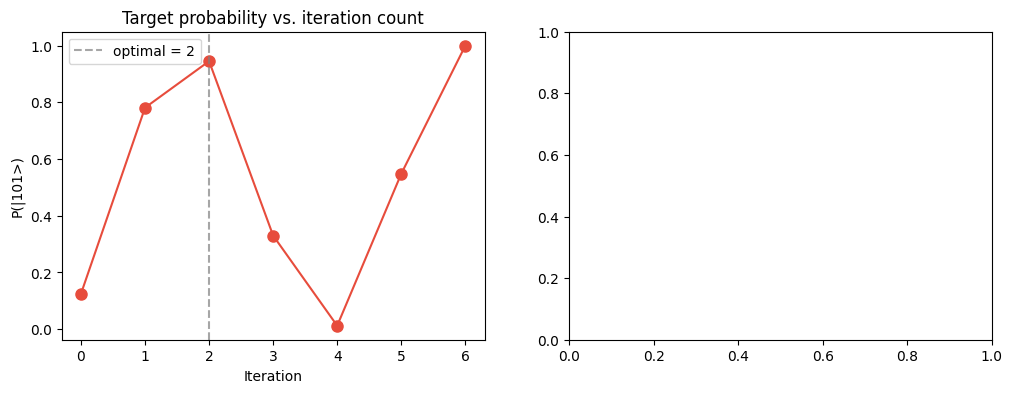

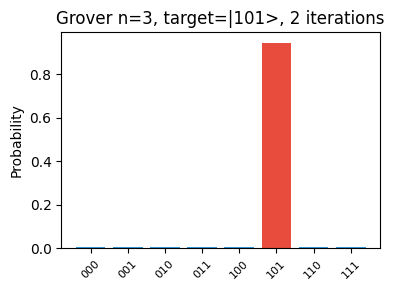

<Figure size 640x480 with 0 Axes>

In [24]:
# Probability amplification over iterations for n=3, target=|101>

n = 3

target = 5

N = 2**n



oracle = np.eye(N)

oracle[target, target] = -1

diffusion = -np.eye(N) + (2/N) * np.ones((N, N))



state = hadamard(n) @ basis_state(n, 0)

max_iters = 6

target_probs = [np.abs(state[target])**2]



for i in range(max_iters):

    state = diffusion @ (oracle @ state)

    target_probs.append(np.abs(state[target])**2)



optimal = floor(pi/4 * sqrt(N))



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))



# Left: probability vs iteration

ax1.plot(range(len(target_probs)), target_probs, 'o-', color='#e74c3c', markersize=8)

ax1.axvline(optimal, color='gray', linestyle='--', alpha=0.7, label=f'optimal = {optimal}')

ax1.set_xlabel('Iteration')

ax1.set_ylabel('P(|101>)')

ax1.set_title('Target probability vs. iteration count')

ax1.legend()



# Right: final state after optimal iterations

state_opt, _ = grover(n, target)

plot_probs(state_opt, n, title=f'Grover n=3, target=|101>, {optimal} iterations', highlight=target)

plt.tight_layout()

plt.show()

**Exercise 6.4.4.** Do the two operations again on the sequence of five numbers [10,10,10,-10,10]. Did our results improve?



*Solution.*

In [25]:
# Exercise 6.4.4

v = np.array([2, 2, 2, 22, 2], dtype=float)  # After 2 iterations from textbook

print(f'After 2 iterations: {v}')

print(f'Difference: {v[3] - v[0]}')



# Phase inversion on 4th element

v[3] = -v[3]

print(f'After phase inversion: {v}')



# Inversion about mean

a = np.mean(v)

v_new = -v + 2*a

print(f'Mean = {a}')

print(f'After inversion about mean: {v_new}')

print(f'Difference: {v_new[3] - v_new[0]}')

print('Yes, the separation increases with each iteration.')

After 2 iterations: [ 2.  2.  2. 22.  2.]
Difference: 20.0
After phase inversion: [  2.   2.   2. -22.   2.]
Mean = -2.8
After inversion about mean: [-7.6 -7.6 -7.6 16.4 -7.6]
Difference: 24.0
Yes, the separation increases with each iteration.


**Exercise 6.4.5.** Do a similar analysis for $n=4$ and $f$ choosing the string "1101".



*Solution.* With $n=4$, we have $N=16$ states. The target is $|1101\rangle = |13\rangle$. The optimal 
number of iterations is $\lfloor\sqrt{16}\rfloor = \lfloor\frac{\pi}{4} \cdot 4\rfloor = 3$.

n=4, target=|1101>, N=16, iterations=3
P(target) = 0.9613
Measured state: |1101>


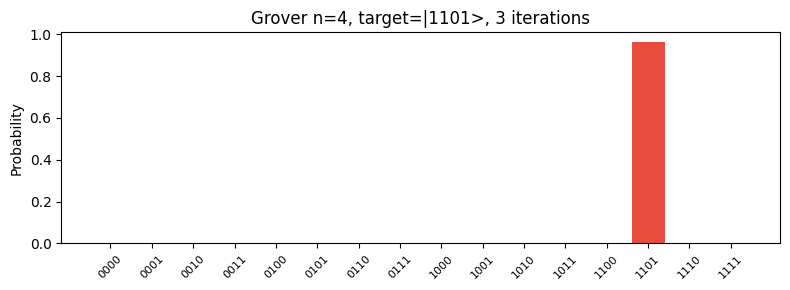

In [26]:
# Exercise 6.4.5: n=4, target = 1101 = 13

n = 4

target = 0b1101  # 13

N = 2**n

optimal = floor(pi/4 * sqrt(N))



state, traced = grover(n, target, trace=True)

probs = np.abs(state)**2



print(f'n={n}, target=|{format(target, f"0{n}b")}>, N={N}, iterations={optimal}')

print(f'P(target) = {probs[target]:.4f}')

print(f'Measured state: |{format(np.argmax(probs), f"0{n}b")}>')



plot_probs(state, n, title=f'Grover n=4, target=|1101>, {optimal} iterations', highlight=target)

## 6.5 Shor's Factoring Algorithm



The security of RSA encryption rests on the difficulty of factoring large integers. The best 
known classical algorithms run in sub-exponential time. Shor's algorithm factors $N$ in 
polynomial time on a quantum computer: $O(n^2 \log n \log \log n)$ where $n = \lceil \log_2 N \rceil$.



The core idea: factoring reduces to finding the period of a modular exponentiation function. 
A quantum computer finds that period exponentially faster than any known classical method.



### Modular exponentiation



For a positive integer $N$ and a co-prime base $a < N$ (meaning $\gcd(a, N) = 1$), define:



$$f_{a,N}(x) = a^x \bmod N$$



This function is periodic: there exists a smallest $r$ (the **period**) such that $a^r \equiv 1 \pmod{N}$.

**Exercise 6.5.1.** Calculate: (i) 244,443 Mod 247, (ii) 18,154 Mod 247, (iii) 226,006 Mod 247.



*Solution.*

In [27]:
# Exercise 6.5.1

print(f'244443 mod 247 = {244443 % 247}')

print(f'18154 mod 247  = {18154 % 247}')

print(f'226006 mod 247 = {226006 % 247}')

244443 mod 247 = 160
18154 mod 247  = 123
226006 mod 247 = 1


**Exercise 6.5.2.** Show that: (i) 1,977 $\equiv$ 1 Mod 247, (ii) 16,183 $\equiv$ 15,442 Mod 247, (iii) 2,439,593 $\equiv$ 238,082 Mod 247.



*Solution.*

In [28]:
# Exercise 6.5.2

print(f'1977 mod 247 = {1977 % 247}  (should be 1)')

print(f'16183 mod 247 = {16183 % 247}, 15442 mod 247 = {15442 % 247}  (should match)')

print(f'2439593 mod 247 = {2439593 % 247}, 238082 mod 247 = {238082 % 247}  (should match)')

1977 mod 247 = 1  (should be 1)
16183 mod 247 = 128, 15442 mod 247 = 128  (should match)
2439593 mod 247 = 221, 238082 mod 247 = 221  (should match)


### Modular exponentiation tables and periodicity



The period of $f_{a,N}$ is the smallest $r$ with $a^r \equiv 1 \pmod{N}$. Finding this period is the 
quantum part of Shor's algorithm.

In [29]:
def mod_exp_table(a, N, num_values=20):

    """Compute a^x mod N for x = 0, 1, ..., num_values-1."""

    values = []

    val = 1  # a^0 = 1

    for x in range(num_values):

        values.append(val)

        val = (val * a) % N

    return values



def find_period(a, N):

    """Find the period r of a^x mod N classically."""

    val = a % N

    r = 1

    while val != 1:

        val = (val * a) % N

        r += 1

        if r > N:

            return None  # No period found

    return r



# N = 15 examples from the textbook

print('=== N = 15 ===')

for a in [2, 4, 13]:

    vals = mod_exp_table(a, 15, 16)

    r = find_period(a, 15)

    print(f'a={a:2d}: {vals[:r+3]}... period r={r}')



print('\n=== N = 371 ===')

for a in [2, 6, 24]:

    r = find_period(a, 371)

    vals = mod_exp_table(a, 371, min(10, r+2))

    print(f'a={a:2d}: first {len(vals)} values = {vals}... period r={r}')

=== N = 15 ===
a= 2: [1, 2, 4, 8, 1, 2, 4]... period r=4
a= 4: [1, 4, 1, 4, 1]... period r=2
a=13: [1, 13, 4, 7, 1, 13, 4]... period r=4

=== N = 371 ===
a= 2: first 10 values = [1, 2, 4, 8, 16, 32, 64, 128, 256, 141]... period r=156
a= 6: first 10 values = [1, 6, 36, 216, 183, 356, 281, 202, 99, 223]... period r=26
a=24: first 10 values = [1, 24, 205, 97, 102, 222, 134, 248, 16, 13]... period r=78


**Exercise 6.5.3.** Calculate the first few values of $f_{a,N}$ for $N = 247$ and (i) $a=2$, (ii) $a=17$, (iii) $a=23$.



*Solution.*

In [30]:
# Exercise 6.5.3

for a in [2, 17, 23]:

    vals = mod_exp_table(a, 247, 20)

    r = find_period(a, 247)

    print(f'a={a:2d}, N=247: first values = {vals}')

    print(f'  period r = {r}\n')

a= 2, N=247: first values = [1, 2, 4, 8, 16, 32, 64, 128, 9, 18, 36, 72, 144, 41, 82, 164, 81, 162, 77, 154]
  period r = 36

a=17, N=247: first values = [1, 17, 42, 220, 35, 101, 235, 43, 237, 77, 74, 23, 144, 225, 120, 64, 100, 218, 1, 17]
  period r = 18

a=23, N=247: first values = [1, 23, 35, 64, 237, 17, 144, 101, 100, 77, 42, 225, 235, 218, 74, 220, 120, 43, 1, 23]
  period r = 18



**Exercise 6.5.4.** Find the period of the functions $f_{2,247}$, $f_{17,247}$, and $f_{23,247}$.



*Solution.*

In [31]:
# Exercise 6.5.4

for a in [2, 17, 23]:

    r = find_period(a, 247)

    print(f'Period of f_{a},247: r = {r}')

Period of f_2,247: r = 36
Period of f_17,247: r = 18
Period of f_23,247: r = 18


### Visualizing periodicity: $N=15$, $a=2$

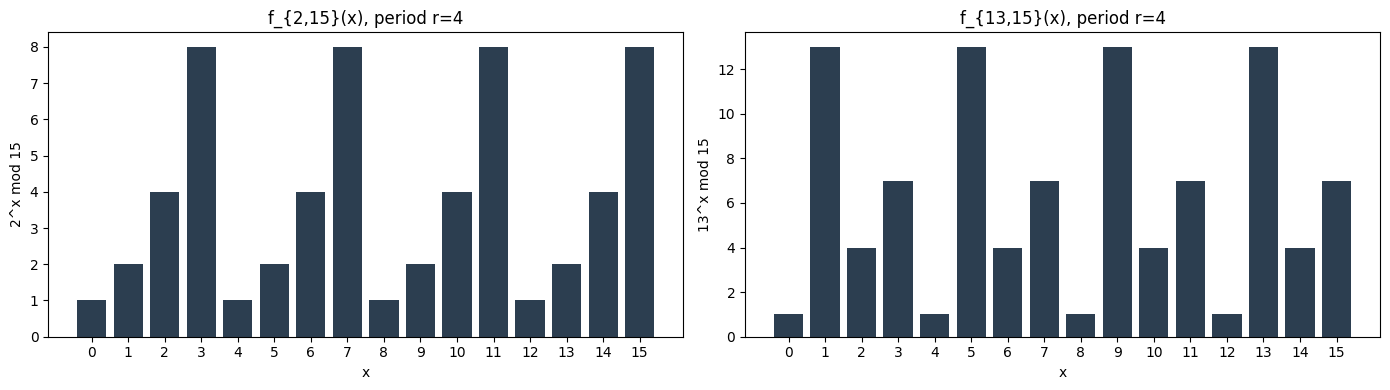

In [32]:
# Bar graph of f_{2,15} and f_{13,15}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))



for ax, a in zip(axes, [2, 13]):

    vals = mod_exp_table(a, 15, 16)

    r = find_period(a, 15)

    ax.bar(range(16), vals, color='#2c3e50')

    ax.set_xlabel('x')

    ax.set_ylabel(f'{a}^x mod 15')

    ax.set_title(f'f_{{{a},15}}(x), period r={r}')

    ax.set_xticks(range(16))



plt.tight_layout()

plt.show()

### The Quantum Fourier Transform (QFT)



The QFT is the quantum version of the discrete Fourier transform (DFT). For $M = 2^m$ 
states, define the $M$th root of unity $\omega = e^{2\pi i / M}$.



The DFT matrix:



$$DFT[j, k] = \frac{1}{\sqrt{M}} \omega^{jk}$$



Its inverse (the $DFT^\dagger$ or $QFT^\dagger$ used in Shor's circuit):



$$DFT^\dagger[j, k] = \frac{1}{\sqrt{M}} \omega^{-jk}$$



The DFT is unitary because $(DFT \cdot DFT^\dagger)[j,k] = \frac{1}{M}\sum_i \omega^{i(j-k)}$, 
which equals 1 when $j=k$ and 0 otherwise (geometric series).



Applied to a periodic superposition with period $r$, the $DFT^\dagger$ produces a superposition 
peaked at multiples of $2^m / r$. This converts the period into something we can measure.

In [33]:
def build_dft(M):

    """Build the M x M DFT matrix."""

    omega = np.exp(2j * pi / M)

    j, k = np.meshgrid(range(M), range(M), indexing='ij')

    return (omega ** (j * k)) / sqrt(M)



def build_dft_dagger(M):

    """Build the M x M inverse DFT (QFT^dagger) matrix."""

    return build_dft(M).conj().T



# Verify unitarity

M = 8

DFT = build_dft(M)

DFT_dag = build_dft_dagger(M)

print(f'DFT is unitary: {np.allclose(DFT @ DFT_dag, np.eye(M))}')



# Show the 4x4 DFT matrix

print(f'\n4x4 DFT matrix (real part):')

DFT4 = build_dft(4)

print(np.round(DFT4.real, 4))

print(f'\n4x4 DFT matrix (imag part):')

print(np.round(DFT4.imag, 4))

DFT is unitary: True

4x4 DFT matrix (real part):
[[ 0.5  0.5  0.5  0.5]
 [ 0.5  0.  -0.5 -0. ]
 [ 0.5 -0.5  0.5 -0.5]
 [ 0.5 -0.  -0.5  0. ]]

4x4 DFT matrix (imag part):
[[ 0.   0.   0.   0. ]
 [ 0.   0.5  0.  -0.5]
 [ 0.   0.  -0.   0. ]
 [ 0.  -0.5  0.   0.5]]


### QFT demo: periodic input to peaked output



If the input state is a uniform superposition over values spaced $r$ apart, the $DFT^\dagger$ 
produces peaks at multiples of $M/r$. This is how Shor's algorithm extracts the period.

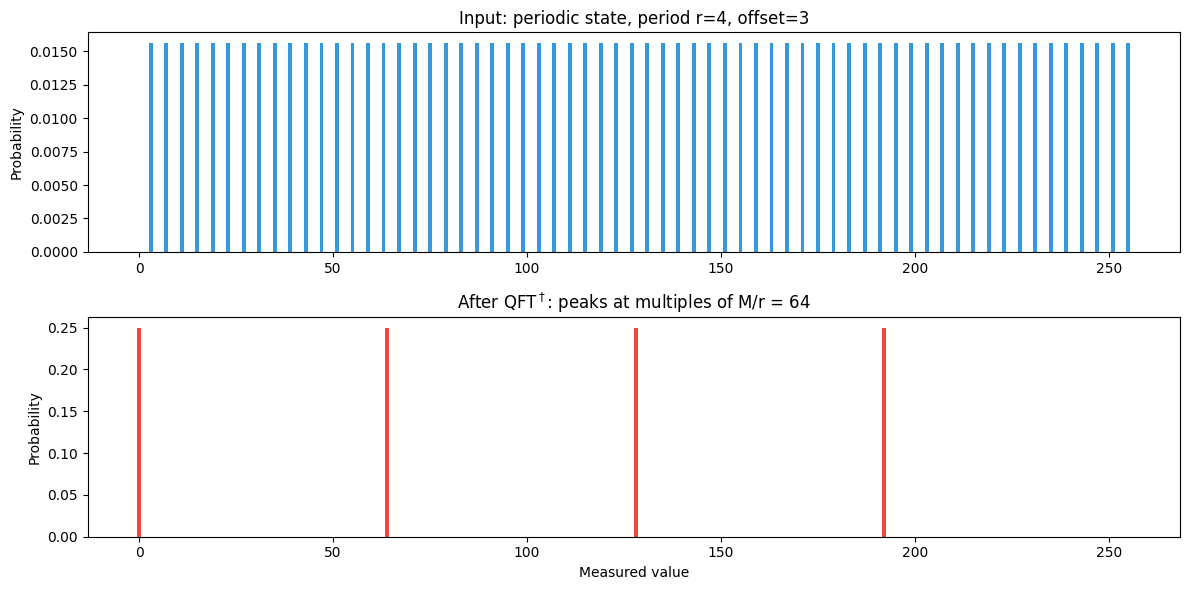

Peaks at: [  0  64 128 192]
Spacing: 64
From any peak x, x/M = lambda/r, reduce fraction to get r


In [34]:
# Demo: QFT^dagger on a periodic state

M = 256  # 2^8

r = 4    # period

offset = 3  # starting offset



# Create periodic state: uniform over {offset, offset+r, offset+2r, ...}

state = np.zeros(M, dtype=complex)

indices = list(range(offset, M, r))

state[indices] = 1.0 / sqrt(len(indices))



# Apply QFT^dagger

DFT_dag = build_dft_dagger(M)

result = DFT_dag @ state

probs = np.abs(result)**2



fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))



ax1.bar(range(M), np.abs(state)**2, color='#3498db', width=1.0)

ax1.set_title(f'Input: periodic state, period r={r}, offset={offset}')

ax1.set_ylabel('Probability')



ax2.bar(range(M), probs, color='#e74c3c', width=1.0)

ax2.set_title(f'After QFT$^\\dagger$: peaks at multiples of M/r = {M//r}')

ax2.set_xlabel('Measured value')

ax2.set_ylabel('Probability')



plt.tight_layout()

plt.show()



# Show the peak positions

peaks = np.where(probs > 0.01)[0]

print(f'Peaks at: {peaks}')

print(f'Spacing: {M // r}')

print(f'From any peak x, x/M = lambda/r, reduce fraction to get r')

**Exercise 6.5.5.** Write the state $|\varphi_2\rangle$ for $N = 247$ and $a = 9$.



*Solution.* With $N=247$, we need $n = \lceil\log_2 247\rceil = 8$ output qubits and $m = 2n = 16$ input qubits. 
The state is:



$$|\varphi_2\rangle = \frac{1}{\sqrt{2^{16}}} \sum_{x=0}^{2^{16}-1} |x, 9^x \bmod 247\rangle$$

In [35]:
# Exercise 6.5.5

a, N = 9, 247

r = find_period(a, N)

n = int(np.ceil(log2(N)))

m = 2 * n

print(f'N={N}, a={a}, n={n}, m={m}')

print(f'Period r = {r}')

print(f'|phi2> = (1/sqrt({2**m})) * sum_x |x, {a}^x mod {N}>')

# Show first few terms

for x in range(8):

    print(f'  x={x}: |{x}, {pow(a, x, N)}>')

N=247, a=9, n=8, m=16
Period r = 9
|phi2> = (1/sqrt(65536)) * sum_x |x, 9^x mod 247>
  x=0: |0, 1>
  x=1: |1, 9>
  x=2: |2, 81>
  x=3: |3, 235>
  x=4: |4, 139>
  x=5: |5, 16>
  x=6: |6, 144>
  x=7: |7, 61>


**Exercise 6.5.6.** Continuing Exercise 6.5.5, let us say that after measuring the bottom qubits, 55 is found. What would $|\varphi_3\rangle$ be?



*Solution.* After measuring 55 in the bottom register, $|\varphi_3\rangle$ becomes a uniform superposition 
over all $x$ values where $9^x \equiv 55 \pmod{247}$, spaced $r$ apart.

In [36]:
# Exercise 6.5.6

a, N, measured = 9, 247, 55

r = find_period(a, N)

m = 16

# Find all x where a^x mod N == measured

x_vals = [x for x in range(2**m) if pow(a, x, N) == measured]

print(f'x values where {a}^x mod {N} = {measured}:')

print(f'  First few: {x_vals[:8]}')

print(f'  Spacing: {x_vals[1] - x_vals[0] if len(x_vals) > 1 else "N/A"}')

print(f'  Period r = {r}')

print(f'  Number of terms: {len(x_vals)}')

x values where 9^x mod 247 = 55:
  First few: [8, 17, 26, 35, 44, 53, 62, 71]
  Spacing: 9
  Period r = 9
  Number of terms: 7281


### From period to factors



Once we have the period $r$ (which must be even), we use the identity:



$$a^r \equiv 1 \pmod{N} \implies N \mid (a^{r/2} + 1)(a^{r/2} - 1)$$



Since $N$ divides the product but (assuming $a^{r/2} \not\equiv -1 \pmod{N}$) does not divide either 
factor individually, the factors of $N$ can be found via:



$$\gcd(a^{r/2} + 1, N) \quad \text{and} \quad \gcd(a^{r/2} - 1, N)$$

In [37]:
def shor_classical_postprocess(a, N, r):

    """Given the period r of a^x mod N, extract factors of N."""

    if r % 2 != 0:

        return None, f'Period {r} is odd, choose different a'

    

    half = pow(a, r // 2, N)

    if half == N - 1:  # a^(r/2) = -1 mod N

        return None, f'a^(r/2) = -1 mod N, choose different a'

    

    f1 = gcd(half + 1, N)

    f2 = gcd(half - 1, N)

    

    factors = []

    if 1 < f1 < N:

        factors.append(f1)

    if 1 < f2 < N:

        factors.append(f2)

    

    return factors, f'a^(r/2) = {half}, gcd({half+1},{N})={f1}, gcd({half-1},{N})={f2}'

### Full factoring: $N = 15$

In [38]:
# Factor N = 15 using Shor's algorithm (classical simulation)

N = 15

print(f'Factoring N = {N}')

print(f'Step 1: {N} is not prime (15 = 3 x 5)\n')



for a in [2, 4, 7, 8, 11, 13, 14]:

    g = gcd(a, N)

    if g != 1:

        print(f'  a={a}: gcd({a},{N}) = {g}, found factor directly!')

        continue

    

    r = find_period(a, N)

    factors, info = shor_classical_postprocess(a, N, r)

    print(f'  a={a}: r={r}, {info}')

    if factors:

        print(f'         Factors: {factors}')

Factoring N = 15
Step 1: 15 is not prime (15 = 3 x 5)

  a=2: r=4, a^(r/2) = 4, gcd(5,15)=5, gcd(3,15)=3
         Factors: [5, 3]
  a=4: r=2, a^(r/2) = 4, gcd(5,15)=5, gcd(3,15)=3
         Factors: [5, 3]
  a=7: r=4, a^(r/2) = 4, gcd(5,15)=5, gcd(3,15)=3
         Factors: [5, 3]
  a=8: r=4, a^(r/2) = 4, gcd(5,15)=5, gcd(3,15)=3
         Factors: [5, 3]
  a=11: r=2, a^(r/2) = 11, gcd(12,15)=3, gcd(10,15)=5
         Factors: [3, 5]
  a=13: r=4, a^(r/2) = 4, gcd(5,15)=5, gcd(3,15)=3
         Factors: [5, 3]
  a=14: r=2, a^(r/2) = -1 mod N, choose different a


**Exercise 6.5.7.** Use the fact that the period of $f_{7,247}$ is 12 to determine the factors of 247.



*Solution.*

In [39]:
# Exercise 6.5.7: Factor 247 using a=7, r=12

a, N, r = 7, 247, 12

print(f'a={a}, N={N}, r={r}')



# Verify period

print(f'Verify: {a}^{r} mod {N} = {pow(a, r, N)}')



half_power = pow(a, r // 2, N)

print(f'{a}^({r}//2) mod {N} = {a}^{r//2} mod {N} = {half_power}')

print(f'{half_power} != {N-1}, so we can proceed')



f1 = gcd(half_power + 1, N)

f2 = gcd(half_power - 1, N)

print(f'gcd({half_power + 1}, {N}) = {f1}')

print(f'gcd({half_power - 1}, {N}) = {f2}')

print(f'\n247 = {f1} x {f2}')

a=7, N=247, r=12
Verify: 7^12 mod 247 = 1
7^(12//2) mod 247 = 7^6 mod 247 = 77
77 != 246, so we can proceed
gcd(78, 247) = 13
gcd(76, 247) = 19

247 = 13 x 19


### Shor's algorithm: the five steps



**Input:** A positive integer $N$ with $n = \lceil \log_2 N \rceil$.



**Output:** A factor $p$ of $N$ if it exists.



**Step 1.** Check if $N$ is prime or a prime power. If so, declare it and exit.



**Step 2.** Randomly choose $1 < a < N$. Compute $\gcd(a, N)$. If it is not 1, return it.



**Step 3.** Use the quantum circuit to find the period $r$ of $f_{a,N}(x) = a^x \bmod N$.



**Step 4.** If $r$ is odd or $a^{r/2} \equiv -1 \pmod{N}$, return to Step 2 with a different $a$.



**Step 5.** Compute $\gcd(a^{r/2}+1, N)$ and $\gcd(a^{r/2}-1, N)$. Return the nontrivial factors.



The quantum circuit:



$$(\text{Measure} \otimes I)(QFT^\dagger \otimes I)(I \otimes \text{Measure})U_{f_{a,N}}(H^{\otimes m} \otimes I)|\mathbf{0}_m, \mathbf{0}_n\rangle$$



The complexity is $O(n^2 \log n \log \log n)$, polynomial in the number of digits. Classical 
algorithms require $O(e^{cn^{1/3} \log^{2/3} n})$, which is sub-exponential but still far slower.

In [40]:
def shor_factor(N, max_attempts=20):

    """Classical simulation of Shor's algorithm to factor N."""

    def is_prime(n):

        if n < 2: return False

        if n < 4: return True

        if n % 2 == 0 or n % 3 == 0: return False

        i = 5

        while i * i <= n:

            if n % i == 0 or n % (i + 2) == 0: return False

            i += 6

        return True

    

    if N < 2:

        return None

    if is_prime(N):

        print(f'{N} is prime')

        return None

    

    # Check if N is a perfect power

    for b in range(2, int(log2(N)) + 1):

        a_root = round(N ** (1/b))

        for candidate in [a_root - 1, a_root, a_root + 1]:

            if candidate > 1 and candidate**b == N:

                print(f'{N} = {candidate}^{b}')

                return candidate

    

    for attempt in range(max_attempts):

        a = np.random.randint(2, N)

        g = gcd(a, N)

        if g != 1:

            print(f'Lucky: gcd({a}, {N}) = {g}')

            return g

        

        r = find_period(a, N)

        if r is None or r % 2 != 0:

            continue

        

        half = pow(a, r // 2, N)

        if half == N - 1:

            continue

        

        f1 = gcd(half + 1, N)

        f2 = gcd(half - 1, N)

        

        for f in [f1, f2]:

            if 1 < f < N:

                print(f'a={a}, r={r}, factor={f}')

                return f

    

    return None



# Factor several numbers

for N in [15, 21, 35, 247, 371]:

    print(f'\nFactoring N = {N}:')

    np.random.seed(42)

    f = shor_factor(N)

    if f:

        print(f'  {N} = {f} x {N // f}')


Factoring N = 15:
a=8, r=4, factor=5
  15 = 5 x 3

Factoring N = 21:
a=8, r=2, factor=3
  21 = 3 x 7

Factoring N = 35:
Lucky: gcd(30, 35) = 5
  35 = 5 x 7

Factoring N = 247:
Lucky: gcd(104, 247) = 13
  247 = 13 x 19

Factoring N = 371:
a=104, r=52, factor=53
  371 = 53 x 7


### Full quantum simulation: $N=15$, $a=2$



For $N=15$, we need $n=4$ output qubits and $m=8$ input qubits. That is $2^{12} = 4096$ states. 
A full matrix simulation is feasible.

N=15, a=2, n=4, m=8, M=256, actual period r=4

Measured bottom register: 1
Matching x values (first 10): [0, 4, 8, 12, 16, 20, 24, 28, 32, 36]
Number of matching: 64
Spacing: 4

After QFT^dagger, peaks at: [  0  64 128 192]
Expected peaks at multiples of M/r = 256/4 = 64


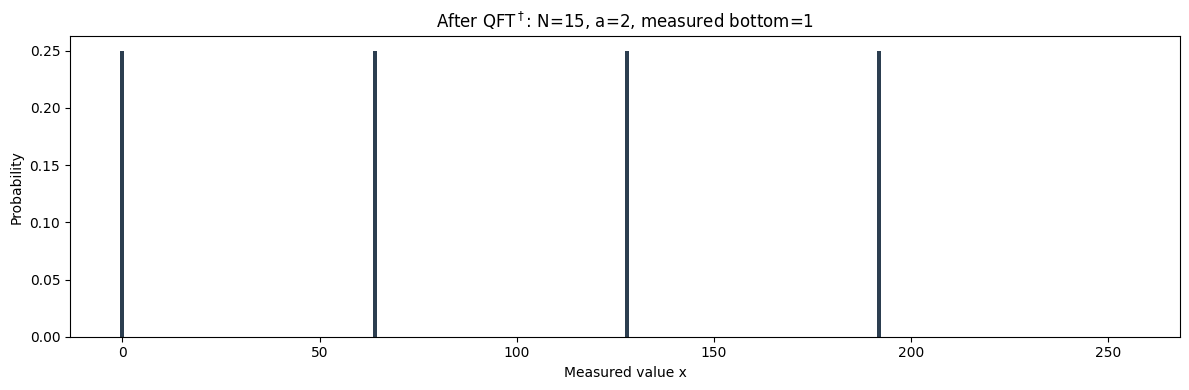


Extracting period from peaks:
  x=64: x/M = 64/256 = 1/4, denominator (candidate r) = 4
  x=128: x/M = 128/256 = 1/2, denominator (candidate r) = 2
  x=192: x/M = 192/256 = 3/4, denominator (candidate r) = 4

Period r = 4
a^(r/2) = 4, gcd(5,15)=5, gcd(3,15)=3
15 = 5 x 3


In [41]:
# Full quantum simulation of Shor for N=15, a=2

N, a = 15, 2

n = 4   # output bits

m = 8   # input bits  (2*n)

M = 2**m  # 256 input states

r_actual = find_period(a, N)

print(f'N={N}, a={a}, n={n}, m={m}, M={M}, actual period r={r_actual}')



# Step 1: Build the state after Hadamard and U_f

# |phi2> = (1/sqrt(M)) sum_x |x, a^x mod N>

# We represent only the top (input) register amplitudes,

# tracking which bottom register value each maps to.



# Build mod-exp values

mod_vals = [pow(a, x, N) for x in range(M)]



# Step 2: Simulate measuring the bottom register

# Pick a measured value (say 1, the first output)

measured_bottom = 1

matching_x = [x for x in range(M) if mod_vals[x] == measured_bottom]

print(f'\nMeasured bottom register: {measured_bottom}')

print(f'Matching x values (first 10): {matching_x[:10]}')

print(f'Number of matching: {len(matching_x)}')

print(f'Spacing: {matching_x[1] - matching_x[0]}')



# Step 3: Build collapsed state and apply QFT^dagger

phi3 = np.zeros(M, dtype=complex)

for x in matching_x:

    phi3[x] = 1.0

phi3 /= np.linalg.norm(phi3)



DFT_dag = build_dft_dagger(M)

phi4 = DFT_dag @ phi3

probs = np.abs(phi4)**2



# Show peaks

peaks = np.where(probs > 0.01)[0]

print(f'\nAfter QFT^dagger, peaks at: {peaks}')

print(f'Expected peaks at multiples of M/r = {M}/{r_actual} = {M//r_actual}')



fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(range(M), probs, color='#2c3e50', width=1.0)

ax.set_xlabel('Measured value x')

ax.set_ylabel('Probability')

ax.set_title(f'After QFT$^\\dagger$: N={N}, a={a}, measured bottom={measured_bottom}')

plt.tight_layout()

plt.show()



# Step 4: Extract period from measurement

print('\nExtracting period from peaks:')

for peak in peaks:

    if peak == 0:

        continue

    frac = Fraction(peak, M).limit_denominator(N)

    print(f'  x={peak}: x/M = {peak}/{M} = {frac}, denominator (candidate r) = {frac.denominator}')



# Step 5: Factor

r = r_actual

factors, info = shor_classical_postprocess(a, N, r)

print(f'\nPeriod r = {r}')

print(info)

if factors:

    print(f'{N} = {" x ".join(map(str, factors))}')

## Summary



| Algorithm | Problem | Speedup | Key Technique |

|-----------|---------|---------|---------------|

| Deutsch | 1-bit balanced vs constant | 2x (1 vs 2 evals) | Phase kickback |

| Deutsch-Jozsa | n-bit balanced vs constant | Exponential ($1$ vs $2^{n-1}+1$) | Phase kickback + $H^{\otimes n}$ |

| Simon | Hidden period (bitwise) | Exponential ($n$ vs $2^{n-1}+1$) | Quantum + GF(2) Gaussian elimination |

| Grover | Unstructured search | Quadratic ($\sqrt{N}$ vs $N$) | Phase inversion + inversion about mean |

| Shor | Integer factoring | Exponential (polynomial vs sub-exponential) | QFT + period finding |



All five algorithms share the same skeleton: start classical, superpose, transform, measure. 
The differences lie in what unitary operations they apply and how they interpret the measurement. 
Deutsch and Deutsch-Jozsa use phase kickback to encode function properties into measurable states. 
Simon adds classical post-processing. Grover iterates two simple operations to amplify probability. 
Shor combines modular exponentiation with the Fourier transform to convert a hidden period into 
a measurable signal.



Each algorithm is, at its core, a change of basis: translating a question that is hard in the 
computational basis into one that is easy in a different basis, answering it there, and translating back.